#  SMS Spam Detection
### TF-IDF + Naive Bayes / Logistic Regression / SVM
Dataset: SMS Spam Collection (5,572 messages)

## Imports & Configuration

In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve
)

warnings.filterwarnings('ignore')
%matplotlib inline

#  Path 
DATA_PATH  = r'C:\Users\vinnu\Downloads\spam.csv'
OUTPUT_DIR = r'C:\Users\vinnu\Downloads\CODSOFT\CODSOFT_task2\outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(' Imports done')

 Imports done


## Load & Explore Data

In [ ]:
print(' Loading data ...')
df = pd.read_csv(DATA_PATH, encoding='latin-1')

# Keep only relevant columns and rename
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print(f'   Total messages : {len(df):,}')
print(f'   Ham  (legit)   : {(df.label=="ham").sum():,}')
print(f'   Spam           : {(df.label=="spam").sum():,}')
print(f'   Spam %         : {(df.label=="spam").mean()*100:.1f}%')
df.head(5)

 Loading data ...
   Total messages : 5,572
   Ham  (legit)   : 4,825
   Spam           : 747
   Spam %         : 13.4%


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## Text Preprocessing

In [ ]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' url ', text)   # replace URLs
    text = re.sub(r'\d+', ' num ', text)               # replace numbers
    text = re.sub(r'[^a-z\s]', ' ', text)             # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['message'].apply(preprocess)

# Add useful features
df['msg_length']   = df['message'].apply(len)
df['word_count']   = df['message'].apply(lambda x: len(x.split()))
df['num_digits']   = df['message'].apply(lambda x: sum(c.isdigit() for c in x))
df['num_upper']    = df['message'].apply(lambda x: sum(c.isupper() for c in x))

print(' Preprocessing done')
print(f'Sample clean message: {df["clean"][2]}')

 Preprocessing done
Sample clean message: free entry in num a wkly comp to win fa cup final tkts num st may num text fa to num to receive entry question std txt rate t c s apply num over num s


## Train / Test Split

In [ ]:
X = df['clean']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Spam in train    : {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Spam in test     : {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Training samples : 4,457
Test samples     : 1,115
Spam in train    : 598 (13.4%)
Spam in test     : 149 (13.4%)


## Train All Models

In [ ]:
tfidf_params = dict(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english'
)

models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_params)),
        ('clf',   MultinomialNB(alpha=0.1))
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_params)),
        ('clf',   LogisticRegression(max_iter=1000, C=5, solver='lbfgs'))
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_params)),
        ('clf',   LinearSVC(max_iter=2000, C=1.0))
    ]),
}

results = {}
predictions = {}

for name, pipe in models.items():
    print(f' Training: {name} ...')
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    predictions[name] = preds
    acc  = accuracy_score(y_test, preds)
    f1   = f1_score(y_test, preds)
    prec = preds[y_test == 1].mean() if preds[y_test == 1].size > 0 else 0
    from sklearn.metrics import precision_score, recall_score
    results[name] = {
        'Accuracy':  acc,
        'Precision': precision_score(y_test, preds),
        'Recall':    recall_score(y_test, preds),
        'F1':        f1
    }
    print(f'   Accuracy: {acc:.4f}  |  Precision: {results[name]["Precision"]:.4f}  |  Recall: {results[name]["Recall"]:.4f}  |  F1: {f1:.4f}')

best_name  = max(results, key=lambda k: results[k]['F1'])
best_preds = predictions[best_name]
print(f'\n Best model: {best_name}')

 Training: Naive Bayes ...
   Accuracy: 0.9874  |  Precision: 0.9856  |  Recall: 0.9195  |  F1: 0.9514
 Training: Logistic Regression ...
   Accuracy: 0.9794  |  Precision: 0.9257  |  Recall: 0.9195  |  F1: 0.9226
 Training: Linear SVM ...
   Accuracy: 0.9857  |  Precision: 0.9524  |  Recall: 0.9396  |  F1: 0.9459

 Best model: Naive Bayes


## Classification Report

In [ ]:
print(f'Classification Report — {best_name}\n')
print(classification_report(y_test, best_preds, target_names=['Ham', 'Spam']))

Classification Report — Naive Bayes

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.99      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



##  Graph 1: Spam vs Ham Distribution

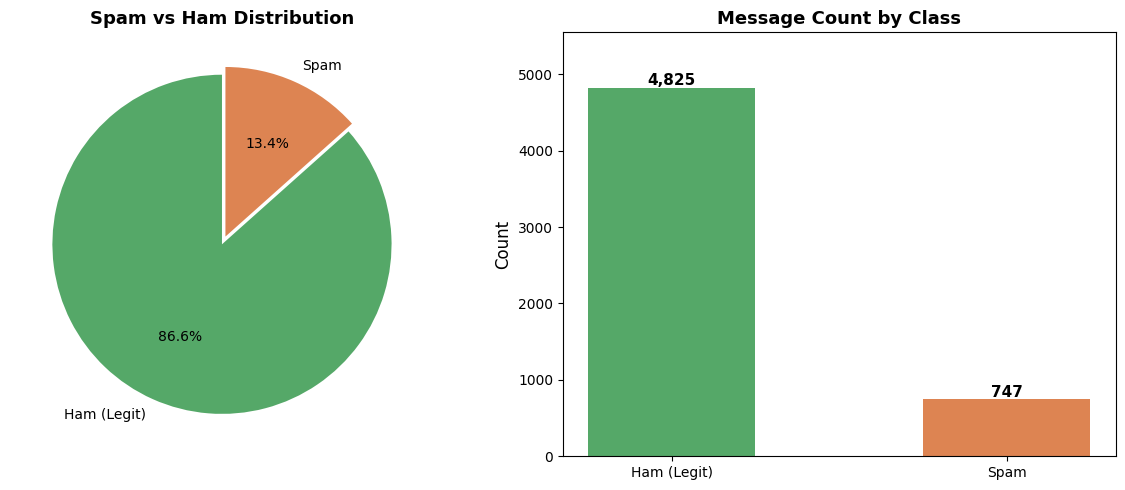

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
counts = df['label'].value_counts()
axes[0].pie(counts, labels=['Ham (Legit)', 'Spam'],
            autopct='%1.1f%%', colors=['#55A868', '#DD8452'],
            startangle=90, explode=(0, 0.05))
axes[0].set_title('Spam vs Ham Distribution', fontsize=13, fontweight='bold')

# Bar chart
axes[1].bar(['Ham (Legit)', 'Spam'], counts.values,
            color=['#55A868', '#DD8452'], width=0.5)
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 30, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Message Count by Class', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.show()

##  Graph 2: Message Length Distribution

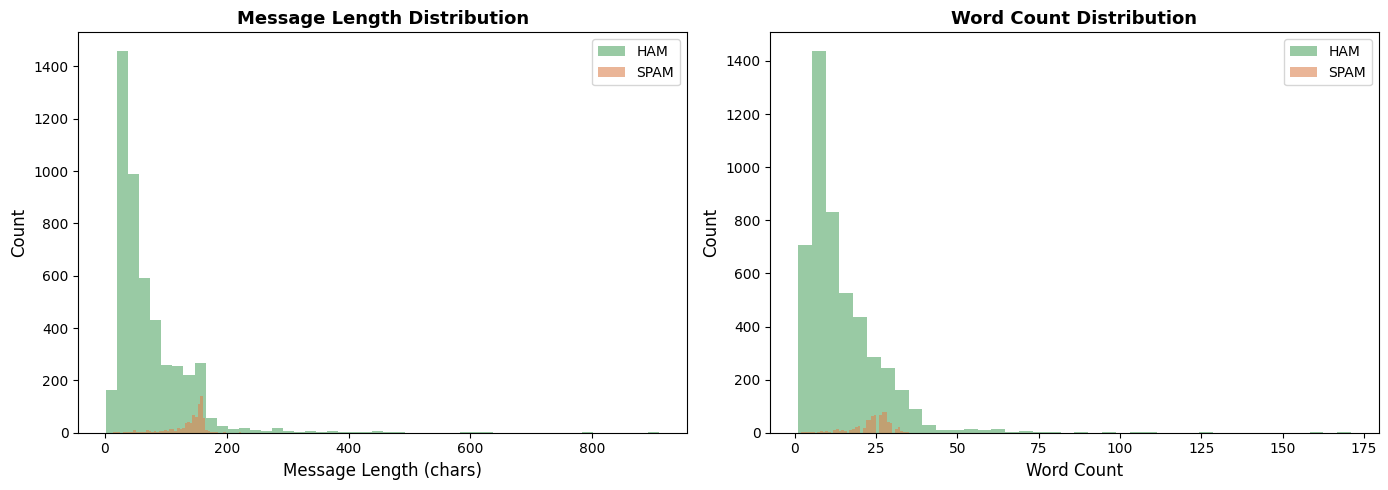

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [('ham', '#55A868'), ('spam', '#DD8452')]:
    axes[0].hist(df[df['label']==label]['msg_length'],
                 bins=50, alpha=0.6, color=color, label=label.upper())
axes[0].set_xlabel('Message Length (chars)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Message Length Distribution', fontsize=13, fontweight='bold')
axes[0].legend()

for label, color in [('ham', '#55A868'), ('spam', '#DD8452')]:
    axes[1].hist(df[df['label']==label]['word_count'],
                 bins=40, alpha=0.6, color=color, label=label.upper())
axes[1].set_xlabel('Word Count', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

##  Graph 3: Model Performance Comparison

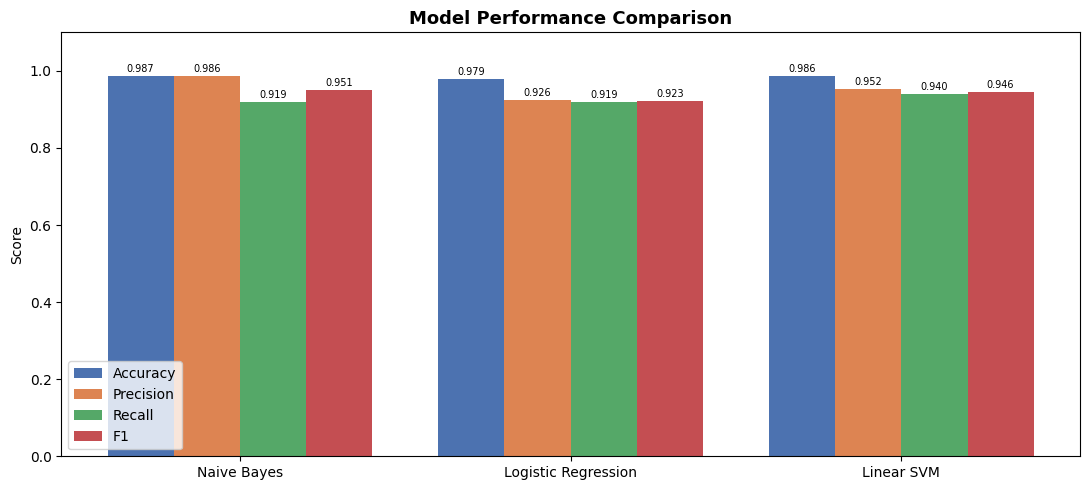

In [ ]:
metrics_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(metrics_df))
width = 0.2
metric_list = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (metric, color) in enumerate(zip(metric_list, colors)):
    vals  = metrics_df[metric].values
    rects = ax.bar(x + i*width, vals, width, label=metric, color=color)
    for rect in rects:
        ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.005,
                f'{rect.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_df['Model'], fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

##  Graph 4: Confusion Matrix (Best Model)

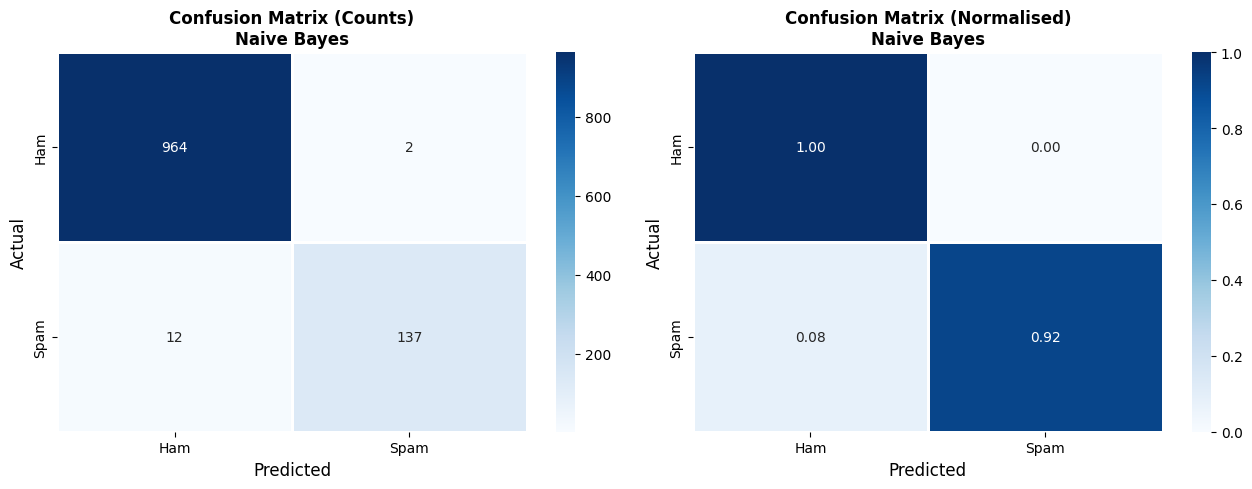

In [ ]:
cm = confusion_matrix(y_test, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            linewidths=1, ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title(f'Confusion Matrix (Counts)\n{best_name}', fontsize=12, fontweight='bold')

# Normalised
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            linewidths=1, ax=axes[1], vmin=0, vmax=1)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title(f'Confusion Matrix (Normalised)\n{best_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

##  Graph 5: Top Spam & Ham Keywords

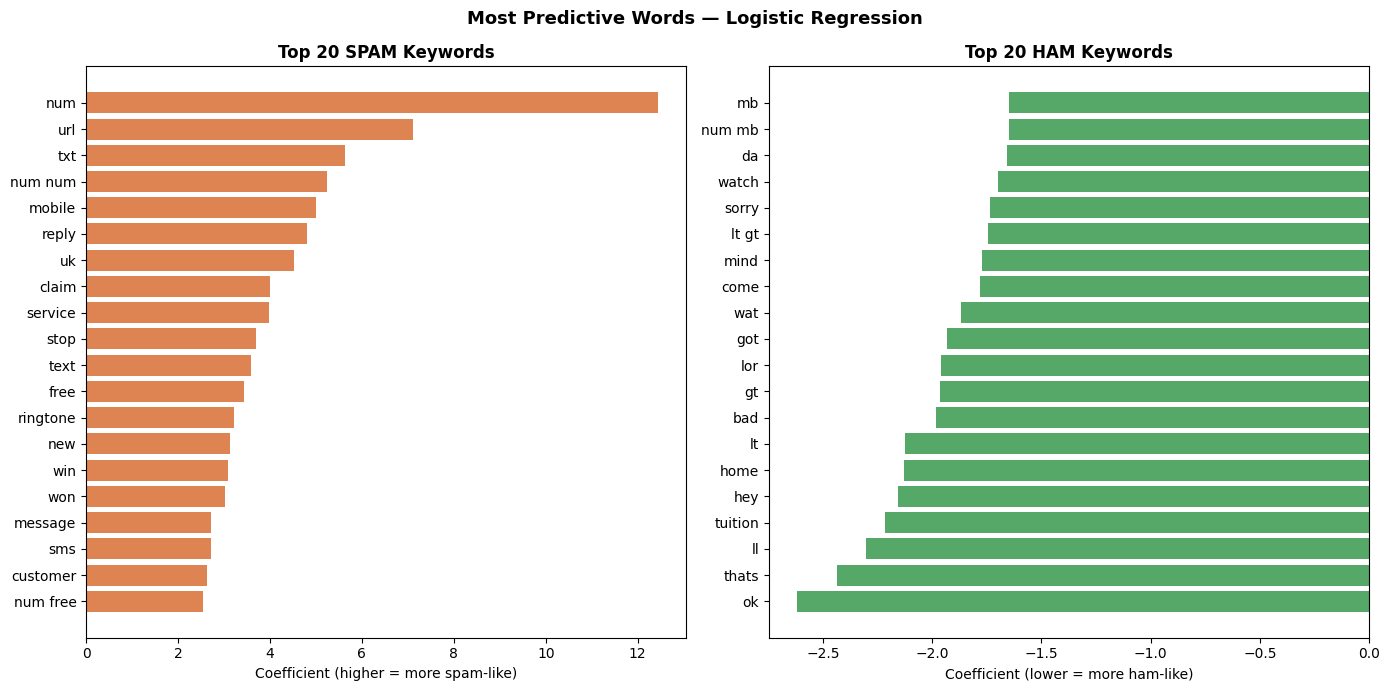

In [ ]:
lr_pipe       = models['Logistic Regression']
vectorizer    = lr_pipe.named_steps['tfidf']
clf           = lr_pipe.named_steps['clf']
feature_names = vectorizer.get_feature_names_out()
coefs         = clf.coef_[0]

top_spam = np.argsort(coefs)[-20:]
top_ham  = np.argsort(coefs)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(feature_names[top_spam], coefs[top_spam], color='#DD8452')
axes[0].set_title('Top 20 SPAM Keywords', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient (higher = more spam-like)')

axes[1].barh(feature_names[top_ham], coefs[top_ham], color='#55A868')
axes[1].set_title('Top 20 HAM Keywords', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coefficient (lower = more ham-like)')

plt.suptitle('Most Predictive Words — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##  Graph 6: ROC Curve

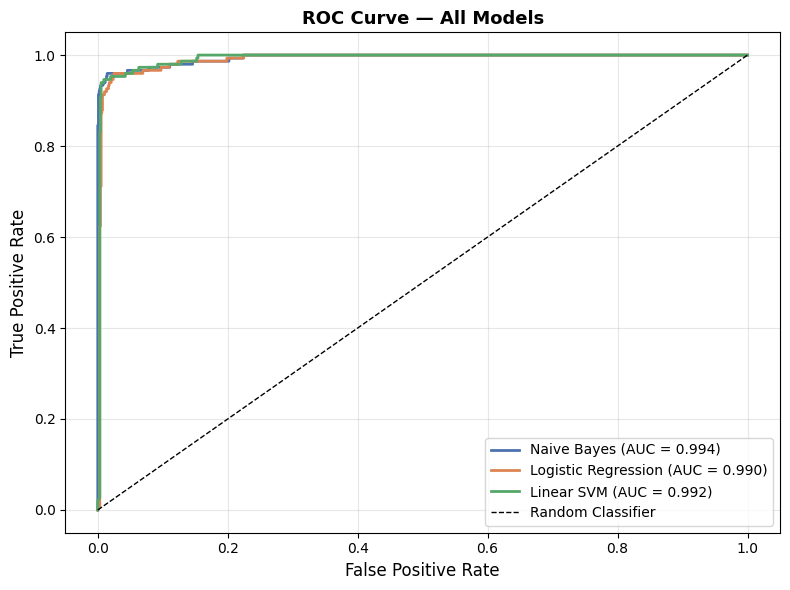

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C72B0', '#DD8452', '#55A868']

for (name, pipe), color in zip(models.items(), colors):
    if hasattr(pipe.named_steps['clf'], 'predict_proba'):
        proba = pipe.predict_proba(X_test)[:, 1]
    else:
        proba = pipe.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##  Graph 7: Cross Validation Scores

Naive Bayes: mean=0.9502  std=0.0139
Logistic Regression: mean=0.9353  std=0.0142
Linear SVM: mean=0.9442  std=0.0114


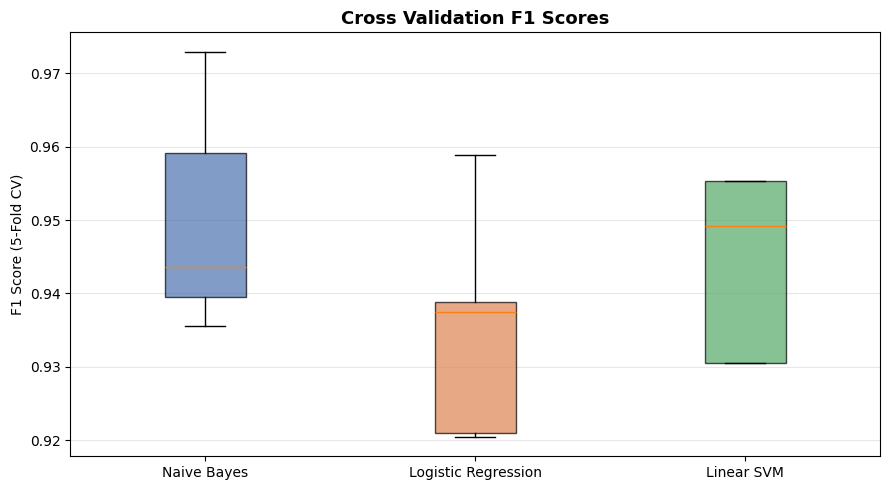

In [ ]:
cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y, cv=5, scoring='f1')
    cv_results[name] = scores
    print(f'{name}: mean={scores.mean():.4f}  std={scores.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
positions = range(len(cv_results))
bp = ax.boxplot(cv_results.values(), patch_artist=True, positions=positions)
colors_bp = ['#4C72B0', '#DD8452', '#55A868']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(positions)
ax.set_xticklabels(cv_results.keys(), fontsize=10)
ax.set_ylabel('F1 Score (5-Fold CV)')
ax.set_title('Cross Validation F1 Scores', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Predict Your Own Message

In [ ]:
def predict_message(message):
    clean = preprocess(message)
    pipe  = models[best_name]
    pred  = pipe.predict([clean])[0]
    if hasattr(pipe.named_steps['clf'], 'predict_proba'):
        prob = pipe.predict_proba([clean])[0][1]
    else:
        prob = pipe.decision_function([clean])[0]
        prob = 1 / (1 + np.exp(-prob))  # sigmoid
    label = ' SPAM' if pred == 1 else ' HAM (Legit)'
    print(f'Message  : {message}')
    print(f'Result   : {label}')
    print(f'Spam prob: {prob:.2%}')
    print('-' * 50)

# Test examples
predict_message('Congratulations! You won a FREE iPhone. Click here to claim now!')
predict_message('Hey, are we still meeting for lunch tomorrow?')
predict_message('URGENT: Your account will be suspended. Call 08001234567 immediately!')
predict_message('Ok sounds good, see you at 6pm')

Message  : Congratulations! You won a FREE iPhone. Click here to claim now!
Result   :  SPAM
Spam prob: 97.88%
--------------------------------------------------
Message  : Hey, are we still meeting for lunch tomorrow?
Result   :  HAM (Legit)
Spam prob: 0.03%
--------------------------------------------------
Message  : URGENT: Your account will be suspended. Call 08001234567 immediately!
Result   :  SPAM
Spam prob: 95.77%
--------------------------------------------------
Message  : Ok sounds good, see you at 6pm
Result   :  HAM (Legit)
Spam prob: 1.01%
--------------------------------------------------


## Final Summary

In [ ]:
print('=' * 55)
print('  FINAL RESULTS SUMMARY')
print('=' * 55)
for name, scores in results.items():
    marker = ' ' if name == best_name else ''
    print(f'\n{name}{marker}')
    for metric, val in scores.items():
        print(f'   {metric:<12}: {val:.4f}')
print('=' * 55)

  FINAL RESULTS SUMMARY

Naive Bayes 
   Accuracy    : 0.9874
   Precision   : 0.9856
   Recall      : 0.9195
   F1          : 0.9514

Logistic Regression
   Accuracy    : 0.9794
   Precision   : 0.9257
   Recall      : 0.9195
   F1          : 0.9226

Linear SVM
   Accuracy    : 0.9857
   Precision   : 0.9524
   Recall      : 0.9396
   F1          : 0.9459
